In [1]:
# Célula 1 — imports e utilitários comuns

from __future__ import annotations

import random
from collections import defaultdict
from pathlib import Path
from typing import List, Sequence, Tuple

import numpy as np
import torch
from PIL import Image
from sympy.core.random import shuffle
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.transforms import InterpolationMode
%load_ext tensorboard

class CenterCropSquare:
    def __call__(self, img: Image.Image):
        w, h = img.size
        side = min(w, h)
        left = (w - side) // 2
        top = (h - side) // 2
        return img.crop((left, top, left + side, top + side))


def stratified_split_indices_3way(
    targets: Sequence[int],
    val_split: float = 0.1,
    test_split: float = 0.1,
    seed: int = 42,
) -> Tuple[List[int], List[int], List[int]]:
    if val_split + test_split >= 1.0:
        raise ValueError("val_split + test_split precisa ser < 1.")

    rng = random.Random(seed)
    by_class = defaultdict(list)

    for idx, label in enumerate(targets):
        by_class[int(label)].append(idx)

    train_idx, val_idx, test_idx = [], [], []

    for indices in by_class.values():
        rng.shuffle(indices)
        n = len(indices)

        if n == 1:
            train_idx.extend(indices)
            continue

        if n == 2:
            train_idx.append(indices[0])
            val_idx.append(indices[1])
            continue

        n_val = max(1, int(round(n * val_split)))
        n_test = max(1, int(round(n * test_split)))

        if n_val + n_test >= n:
            n_val = max(1, n_val - 1)

        val_idx.extend(indices[:n_val])
        test_idx.extend(indices[n_val:n_val + n_test])
        train_idx.extend(indices[n_val + n_test:])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return train_idx, val_idx, test_idx


class ImageFolderSubset(Dataset):
    def __init__(self, base_dataset: ImageFolder, indices: Sequence[int], transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        path, target = self.base_dataset.samples[real_idx]
        img = self.base_dataset.loader(path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, target

## Funções utilitárias para analisar os modelos e visualizar os dados

In [2]:
# Célula 2 — utilitários genéricos

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
def collect_predictions(model, loader, device, unpack_batch):
    """
    unpack_batch(batch, device) deve retornar:
      - inputs: tensor ou tupla de tensores
      - targets: tensor de labels
    """
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            inputs, targets = unpack_batch(batch, device)

            if isinstance(inputs, tuple):
                logits = model(*inputs)
            else:
                logits = model(inputs)

            preds = logits.argmax(dim=1)

            y_true.append(targets.detach().cpu().numpy())
            y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return y_true, y_pred


def analyze_predictions(y_true, y_pred, class_names, top_k_worst=10, top_k_confusions=15):
    """
    Retorna:
      - df_worst_classes: classes com menor accuracy
      - df_top_confusions: maiores confusões fora da diagonal
      - cm: matriz de confusão
      - report: classification_report em dict
    """
    n_classes = len(class_names)
    labels = np.arange(n_classes)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    row_sum = cm.sum(axis=1)
    class_acc = np.divide(
        np.diag(cm),
        row_sum,
        out=np.zeros_like(np.diag(cm), dtype=float),
        where=row_sum != 0,
    )

    df_worst_classes = pd.DataFrame({
        "class_id": labels,
        "class_name": class_names,
        "support": row_sum,
        "correct": np.diag(cm),
        "class_accuracy": class_acc,
    }).sort_values("class_accuracy", ascending=True).head(top_k_worst)

    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)

    total_errors = cm_off.sum()
    rows = []

    if total_errors > 0:
        flat_indices = np.argsort(cm_off.ravel())[::-1]
        for flat_idx in flat_indices:
            count = cm_off.ravel()[flat_idx]
            if count == 0:
                break

            i, j = np.unravel_index(flat_idx, cm_off.shape)

            rows.append({
                "true_class_id": i,
                "true_class_name": class_names[i],
                "pred_class_id": j,
                "pred_class_name": class_names[j],
                "count": int(count),
                "row_normalized_rate": float(count / row_sum[i]) if row_sum[i] > 0 else 0.0,
                "global_error_share": float(count / total_errors),
            })

            if len(rows) >= top_k_confusions:
                break

    df_top_confusions = pd.DataFrame(rows)

    return df_worst_classes, df_top_confusions, cm, report


def print_analysis(df_worst_classes, df_top_confusions, report, title=""):
    if title:
        print(f"\n=== {title} ===")

    print("\nClasses com menor accuracy:")
    display(df_worst_classes)

    print("\nMaiores confusões fora da diagonal:")
    display(df_top_confusions)

    print("\nResumo geral:")
    print(f"Accuracy total: {report['accuracy']:.4f}")

    # opcional: mostra algumas métricas por classe em formato compacto
    per_class = []
    for k, v in report.items():
        if isinstance(v, dict) and k not in ("macro avg", "weighted avg"):
            per_class.append((k, v["precision"], v["recall"], v["f1-score"], v["support"]))

    df_report = pd.DataFrame(
        per_class,
        columns=["class_name", "precision", "recall", "f1", "support"]
    ).sort_values("recall", ascending=True)

    print("\nClasses ordenadas por menor recall:")
    display(df_report.head(10))

## Data loader Imagens

In [3]:
# Célula 2 — DataLoaders para o modelo que usa a imagem

def build_image_dataloaders(
    root_dir: str | Path = "photos/dataset",
    batch_size: int = 32,
    val_split: float = 0.1,
    test_split: float = 0.1,
    seed: int = 42,
    num_workers: int = 4,
):
    root_dir = Path(root_dir)
    base_dataset = ImageFolder(root=str(root_dir))

    train_idx, val_idx, test_idx = stratified_split_indices_3way(
        targets=base_dataset.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    # Sem augmentation; apenas o preprocessing que você definiu.
    train_transform = transforms.Compose([
        CenterCropSquare(),
        transforms.Resize((500, 500), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
    ])

    eval_transform = transforms.Compose([
        CenterCropSquare(),
        transforms.Resize((500, 500), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
    ])

    train_dataset = ImageFolderSubset(base_dataset, train_idx, transform=train_transform)
    val_dataset   = ImageFolderSubset(base_dataset, val_idx, transform=eval_transform)
    test_dataset  = ImageFolderSubset(base_dataset, test_idx, transform=eval_transform)

    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )

    return train_loader, val_loader, test_loader, base_dataset.classes, base_dataset.class_to_idx

## Data load Histogramas

In [4]:
# Célula 3 — histogramas RGB e DataLoaders para o modelo de histograma

def rgb_histogram_tensor(
    img: Image.Image,
    bins: int = 256,
    normalize_hist: bool = False,
) -> torch.Tensor:
    """
    Retorna um vetor 1D com 3*bins valores: [R_hist | G_hist | B_hist].
    Se normalize_hist=True, cada canal soma 1.
    """
    img = img.convert("RGB")
    arr = np.asarray(img)  # shape: H x W x 3

    feats = []
    for c in range(3):
        hist, _ = np.histogram(arr[..., c], bins=bins, range=(0, 256))
        hist = hist.astype(np.float32)
        if normalize_hist:
            hist /= (hist.sum() + 1e-8)
        feats.append(hist)

    return torch.from_numpy(np.concatenate(feats, axis=0))


class HistogramFolderSubset(Dataset):
    def __init__(
        self,
        base_dataset: ImageFolder,
        indices: Sequence[int],
        bins: int = 256,
        normalize_hist: bool = False,
    ):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.bins = bins
        self.normalize_hist = normalize_hist

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        path, target = self.base_dataset.samples[real_idx]
        img = self.base_dataset.loader(path).convert("RGB")
        hist = rgb_histogram_tensor(img, bins=self.bins, normalize_hist=self.normalize_hist)
        return hist, target


def build_histogram_dataloaders(
    root_dir: str | Path = "photos/dataset",
    batch_size: int = 32,
    val_split: float = 0.1,
    test_split: float = 0.1,
    seed: int = 42,
    num_workers: int = 4,
    bins: int = 256,
    normalize_hist: bool = True,
):
    root_dir = Path(root_dir)
    base_dataset = ImageFolder(root=str(root_dir))

    train_idx, val_idx, test_idx = stratified_split_indices_3way(
        targets=base_dataset.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    train_dataset = HistogramFolderSubset(
        base_dataset, train_idx, bins=bins, normalize_hist=normalize_hist
    )
    val_dataset = HistogramFolderSubset(
        base_dataset, val_idx, bins=bins, normalize_hist=normalize_hist
    )
    test_dataset = HistogramFolderSubset(
        base_dataset, test_idx, bins=bins, normalize_hist=normalize_hist
    )

    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )

    return train_loader, val_loader, test_loader, base_dataset.classes, base_dataset.class_to_idx

## Imports e hyperparameters para o treinamento dos modelos


In [5]:
# Célula 1 — imports e hiperparâmetros

from __future__ import annotations

import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

# Ajuste aqui os hiperparâmetros do experimento
HYPERPARAMS = {
    "root_dir": "photos/dataset",
    "batch_size": 32,
    "val_split": 0.10,
    "test_split": 0.10,
    "seed": 42,
    "num_workers": 4,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 10,
    "log_dir": "logs",
    "experiment_name": "image_classifier",
}

## Hipóteses sobre os modelos

Analisando os dados, é possível levantar algumas hipóteses sobre o que pode ser relevante para a classificação. Por exemplo, alguns efeitos devem ser extremamente fáceis de indentificar em um histograma, como o efeito de posterização e dithering. Já outros efeitos, como uma aberração cromática, podem ser mais difíceis de identificar apenas por um histograma, e podem exigir uma análise mais detalhada da imagem.

Levantando essa hipótese de que modelos de CNN e baseado em histogramas terão padrões de erros diferentes, a ideia final seŕa utilizar um terceiro modelo de ensemble para combinar os dois modelos anteriores, e tentar obter um resultado consideravelmente melhor do que cada um individualmente.

## Modelo simples para classificação de imagens (CNN)

In [6]:
# Célula 2 — modelo simples

class SimpleImageClassifier(pl.LightningModule):
    def __init__(self, num_classes: int, hparams: dict):
        super().__init__()
        self.save_hyperparameters(hparams)

        self.features = nn.Sequential(
            nn.BatchNorm2d(3),
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 500 -> 250


            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 250 -> 125

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 2*num_classes),
            nn.ReLU(inplace=True),
            nn.Linear(2*num_classes, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _shared_step(self, batch, stage: str):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_acc", acc, prog_bar=True, on_step=False, on_epoch=True)

        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )
        return optimizer

## Treinamento do modelo de classificação de imagens

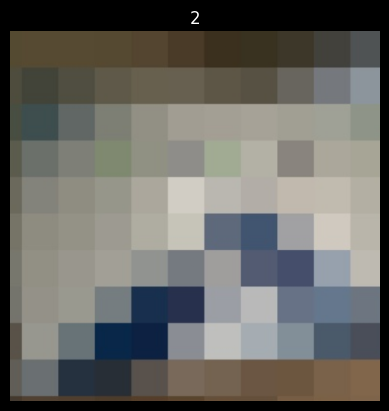

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Classes: 42


You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/bruno/miniconda3/envs/EA979/lib/python3.13/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name       | Type       | Params | Mode  | FLOPs
----------------------------------------------------------
0 | features   | Sequential | 388 K  | train | 0    
1 | classifier | Sequential | 25.2 K | train | 0    
----------------------------------------------------------
414 K     Trainable params
0         Non-trainable params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/bruno/miniconda3/envs/EA979/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 0: 100%|██████████| 193/193 [00:44<00:00,  4.35it/s, v_num=11]       
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 193/193 [00:43<00:00,  4.39it/s, v_num=11, val_loss=1.870, val_acc=0.433, train_loss=2.470, train_acc=0.257]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 193/193 [00:43<00:00,  4.46it/s, v_num=11, val_loss=1.480, val_acc=0.509, train_loss=1.740, train_acc=0.438]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 193/193 [00:42<00:00,  4.50it/s, v_num=11, val_loss=1.330, val_acc=0.562, train_loss=1.490, train_acc=0.517]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 193/193 [00:42<00:00,  4.52it/s, v_num=11, val_loss=1.240, val_acc=0.590, train_loss=1.300, train_acc=0.566]
Validation: |   

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 193/193 [00:44<00:00,  4.29it/s, v_num=11, val_loss=0.884, val_acc=0.675, train_loss=0.909, train_acc=0.674]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Testing DataLoader 0: 100%|██████████| 24/24 [00:01<00:00, 14.97it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7023809552192688
        test_loss           0.8752120733261108
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Classes: ['175807_futuro', '175807_maria_e_sobel', '175807_pixelular', '186629_canny_edge_detection', '186629_chromatic_aberration_blur', '186629_color_splash', '237310_aberracao_cromatica', '237310_pixelizacao', '237310_quantizacao', '241163_chromatic_aberration', '241163_edge_detection', '241163_pixelation', '243360_chromatic_aberration', '243360_edge_detection', '243360_radial_blur', '245609_borda_lapis', '245609_fisheye'

In [7]:
# Célula 3 — dataloaders, logger, trainer e treino
from matplotlib import pyplot as plt
# Usa a função que você já criou antes:
train_loader, val_loader, test_loader, classes, class_to_idx = build_image_dataloaders(
    root_dir=HYPERPARAMS["root_dir"],
    batch_size=HYPERPARAMS["batch_size"],
    val_split=HYPERPARAMS["val_split"],
    test_split=HYPERPARAMS["test_split"],
    seed=HYPERPARAMS["seed"],
    num_workers=HYPERPARAMS["num_workers"],
)
import random
img, label = train_loader.dataset[random.randint(0, train_loader.dataset.__len__())]

plt.imshow(img.permute(1, 2, 0))
plt.title(label)
plt.axis("off")
plt.show()

print(f"Classes: {len(classes)}")
model_image = SimpleImageClassifier(
    num_classes=len(classes),
    hparams=HYPERPARAMS,
)

logger = TensorBoardLogger(
    save_dir=HYPERPARAMS["log_dir"],
    name=HYPERPARAMS["experiment_name"],
)

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{val_loss:.4f}",
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
)

trainer = pl.Trainer(
    max_epochs=HYPERPARAMS["max_epochs"],
    logger=logger,
    callbacks=[checkpoint_cb, early_stop_cb],
    accelerator="auto",
    devices="auto",
    log_every_n_steps=10,
    precision="16-mixed"
)

trainer.fit(model_image, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(model_image, dataloaders=test_loader)
model_image.save_hyperparameters(HYPERPARAMS)
print("Classes:", classes)
print("Class to idx:", class_to_idx)
print("TensorBoard logs em:", logger.log_dir)

In [8]:
# Célula 4 — abrir TensorBoard no notebook, se quiser

%load_ext tensorboard
%tensorboard --logdir logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


## ANalise de erros do modelo de imagem

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_image = model_image.to(device)

def unpack_image_batch(batch, device):
    x, y = batch
    return x.to(device), y.to(device)

y_true_img, y_pred_img = collect_predictions(
    model_image,
    test_loader,
    device,
    unpack_image_batch,
)

df_worst_img, df_conf_img, cm_img, report_img = analyze_predictions(
    y_true_img,
    y_pred_img,
    classes,
    top_k_worst=10,
    top_k_confusions=15,
)

print_analysis(df_worst_img, df_conf_img, report_img, title="Modelo de imagem")



=== Modelo de imagem ===

Classes com menor accuracy:


,class_id,class_name,support,correct,class_accuracy
31,31,260382_difference_of_gaussians_flow,18,0,0.000000
22,22,246955_fish_eye,18,0,0.000000
37,37,260382_effect_identity,18,0,0.000000
41,41,origin,18,1,0.055556
25,25,247145_color_selection,18,2,0.111111
14,14,243360_radial_blur,18,3,0.166667
19,19,245760_deteccao_borda,18,4,0.222222
12,12,243360_chromatic_aberration,18,5,0.277778
26,26,247145_twirl,18,6,0.333333
5,5,186629_color_splash,18,6,0.333333



Maiores confusões fora da diagonal:


,true_class_id,true_class_name,pred_class_id,pred_class_name,count,row_normalized_rate,global_error_share
0,31,260382_difference_of_gaussians_flow,36,260382_edge_detection,18,1.000000,0.079646
1,25,247145_color_selection,18,245760_aberracao_cromatica,16,0.888889,0.070796
2,7,237310_pixelizacao,11,241163_pixelation,11,0.611111,0.048673
3,41,origin,26,247145_twirl,8,0.444444,0.035398
4,14,243360_radial_blur,11,241163_pixelation,7,0.388889,0.030973
5,22,246955_fish_eye,11,241163_pixelation,6,0.333333,0.026549
6,12,243360_chromatic_aberration,26,247145_twirl,6,0.333333,0.026549
7,5,186629_color_splash,18,245760_aberracao_cromatica,5,0.277778,0.022124
8,37,260382_effect_identity,26,247145_twirl,5,0.277778,0.022124
9,22,246955_fish_eye,26,247145_twirl,5,0.277778,0.022124



Resumo geral:
Accuracy total: 0.7011

Classes ordenadas por menor recall:


,class_name,precision,recall,f1,support
31,260382_difference_of_gaussians_flow,0.000000,0.000000,0.000000,18.0
22,246955_fish_eye,0.000000,0.000000,0.000000,18.0
37,260382_effect_identity,0.000000,0.000000,0.000000,18.0
41,origin,0.333333,0.055556,0.095238,18.0
25,247145_color_selection,0.181818,0.111111,0.137931,18.0
14,243360_radial_blur,0.600000,0.166667,0.260870,18.0
19,245760_deteccao_borda,0.666667,0.222222,0.333333,18.0
12,243360_chromatic_aberration,0.416667,0.277778,0.333333,18.0
26,247145_twirl,0.153846,0.333333,0.210526,18.0
5,186629_color_splash,0.545455,0.333333,0.413793,18.0


## Comentários finais sobre o modelo de imagem
De maneira geral os resultados foram bons, e o modelo conseguiu aprender a classificar as imagens com uma acurácia razoável. Analisando os erros, é possível perceber que ele tem mais dificuldade com algumas classes específicas, como as diferentes difference_of_gaussians, o que pode indicar que essas classes têm características visuais mais sutís. Todavia, algumas dessas Classes tem características bem diferentes no histograma, como dithering_red_yellow_black_white e 260382_dithering_red_black_white, portanto um resultado bom é esperado do ensemble.

## Histograma modelo

In [10]:


HYPERPARAMS_HIST = {
    "root_dir": "photos/dataset",
    "batch_size": 64,
    "val_split": 0.10,
    "test_split": 0.10,
    "seed": 42,
    "num_workers": 4,
    "lr": 1e-3,
    "weight_decay": 2e-4,
    "max_epochs": 15,
    "log_dir": "logs",
    "experiment_name": "histogram_classifier",
    # específicos do histograma
    "bins": 64,              # recomendo testar 32 / 64 / 128
    "normalize_hist": True,  # geralmente melhor
    "hidden_dim": 128,
}

## Modelo simples para classificação de histogramas RGB

In [11]:
# Célula 2 — modelo (MLP simples)




class HistogramClassifier(pl.LightningModule):
    def __init__(self, num_classes: int, hparams: dict):
        super().__init__()
        self.save_hyperparameters(hparams)

        input_dim = 3 * self.hparams["bins"]

        self.model = nn.Sequential(
            nn.Linear(input_dim, self.hparams["hidden_dim"]),
            nn.ReLU(),
            nn.Linear(self.hparams["hidden_dim"], self.hparams["hidden_dim"]),
            nn.ReLU(),
            nn.Linear(self.hparams["hidden_dim"], self.hparams["hidden_dim"]),
            nn.ReLU(),
            nn.Linear(self.hparams["hidden_dim"], num_classes),
        )

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch, stage: str):
        x, y = batch  # x shape: [B, 3*bins]
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True)
        self.log(f"{stage}_acc", acc, prog_bar=True, on_epoch=True)

        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, "test")

    def configure_optimizers(self):
        return torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

# Célula 3 — dataloaders, logger, trainer e treino do modelo de histograma

Hist.shape : (192,)


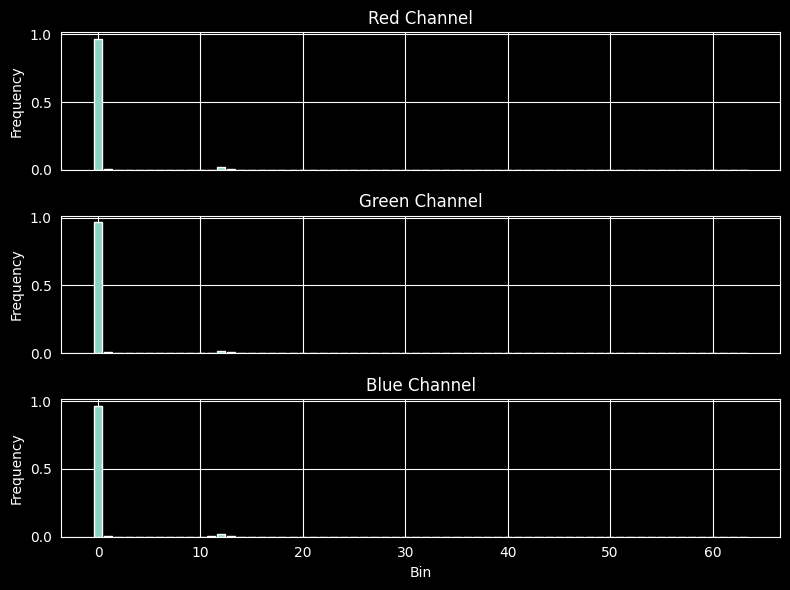

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | Sequential | 63.1 K | train | 0    
-----------------------------------------------------
63.1 K    Trainable params
0         Non-trainable params
63.1 K    Total params
0.253     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/bruno/miniconda3/envs/EA979/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 0: 100%|██████████| 97/97 [00:07<00:00, 12.79it/s, v_num=19, train_loss_step=2.750, train_acc_step=0.100] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 97/97 [00:07<00:00, 13.43it/s, v_num=19, train_loss_step=1.740, train_acc_step=0.367, val_loss=2.600, val_acc=0.168, train_loss_epoch=3.320, train_acc_epoch=0.0901]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 97/97 [00:07<00:00, 13.56it/s, v_num=19, train_loss_step=2.040, train_acc_step=0.333, val_loss=2.070, val_acc=0.384, train_loss_epoch=2.330, train_acc_epoch=0.284] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 97/97 [00:07<00:00, 13.68it/s, v_num=19, train_loss_step=2.090, train_acc_step=0.300, val_loss=1.910, val_acc=0.418, train_loss_epoch=2.010, train_acc_epoch=0.373]
Validation: |          | 0/? [00:00<?, 

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 97/97 [00:08<00:00, 11.59it/s, v_num=19, train_loss_step=1.330, train_acc_step=0.700, val_loss=1.410, val_acc=0.546, train_loss_epoch=1.390, train_acc_epoch=0.542]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Testing DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 19.53it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5410053133964539
        test_loss           1.4303312301635742
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TensorBoard logs em: logs/histogram_classifier/version_19


In [12]:
# Célula 3 — dataloaders de histograma + treino



train_loader, val_loader, test_loader, classes, class_to_idx = build_histogram_dataloaders(
    root_dir=HYPERPARAMS_HIST["root_dir"],
    batch_size=HYPERPARAMS_HIST["batch_size"],
    val_split=HYPERPARAMS_HIST["val_split"],
    test_split=HYPERPARAMS_HIST["test_split"],
    seed=HYPERPARAMS_HIST["seed"],
    num_workers=HYPERPARAMS_HIST["num_workers"],
    bins=HYPERPARAMS_HIST["bins"],
    normalize_hist=HYPERPARAMS_HIST["normalize_hist"],
)

hist, label = train_loader.dataset[random.randint(0, train_loader.dataset.__len__())]

def plot_rgb_hist_bars(hist):
    hist = np.asarray(hist)
    print(f"Hist.shape : {hist.shape}")
    assert hist.shape[0] % 3 == 0, "Histogram must be concatenated RGB"

    n = hist.shape[0] // 3

    r = hist[0:n]
    g = hist[n:2*n]
    b = hist[2*n:3*n]

    x = np.arange(n)

    fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

    axes[0].bar(x, r)
    axes[0].set_title("Red Channel")
    axes[0].set_ylabel("Frequency")

    axes[1].bar(x, g)
    axes[1].set_title("Green Channel")
    axes[1].set_ylabel("Frequency")

    axes[2].bar(x, b)
    axes[2].set_title("Blue Channel")
    axes[2].set_xlabel("Bin")
    axes[2].set_ylabel("Frequency")

    for ax in axes:
        ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_rgb_hist_bars(hist)

model_hist = HistogramClassifier(
    num_classes=len(classes),
    hparams=HYPERPARAMS_HIST,
)

logger = TensorBoardLogger(
    save_dir=HYPERPARAMS_HIST["log_dir"],
    name=HYPERPARAMS_HIST["experiment_name"],
)

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{val_loss:.4f}",
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
)

trainer = pl.Trainer(
    max_epochs=HYPERPARAMS_HIST["max_epochs"],
    logger=logger,
    callbacks=[checkpoint_cb, early_stop_cb],
    accelerator="auto",
    devices="auto",
    log_every_n_steps=10,
)

trainer.fit(model_hist, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(model_hist, dataloaders=test_loader)

print("TensorBoard logs em:", logger.log_dir)
model_hist.save_hyperparameters(HYPERPARAMS_HIST)


In [13]:
%tensorboard --logdir logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 14897), started 0:02:10 ago. (Use '!kill 14897' to kill it.)

In [14]:

def unpack_hist_batch(batch, device):
    x, y = batch
    return x.to(device), y.to(device)

model_hist = model_hist.to(device)

y_true_hist, y_pred_hist = collect_predictions(
    model_hist,
    test_loader,
    device,
    unpack_hist_batch,
)

df_worst_hist, df_conf_hist, cm_hist, report_hist = analyze_predictions(
    y_true_hist,
    y_pred_hist,
    classes,
    top_k_worst=10,
    top_k_confusions=15,
)

print_analysis(df_worst_hist, df_conf_hist, report_hist, title="Modelo de histograma")


=== Modelo de histograma ===

Classes com menor accuracy:


,class_id,class_name,support,correct,class_accuracy
7,7,237310_pixelizacao,18,0,0.000000
4,4,186629_chromatic_aberration_blur,18,0,0.000000
11,11,241163_pixelation,18,0,0.000000
9,9,241163_chromatic_aberration,18,0,0.000000
12,12,243360_chromatic_aberration,18,0,0.000000
26,26,247145_twirl,18,0,0.000000
25,25,247145_color_selection,18,0,0.000000
41,41,origin,18,0,0.000000
31,31,260382_difference_of_gaussians_flow,18,1,0.055556
19,19,245760_deteccao_borda,18,1,0.055556



Maiores confusões fora da diagonal:


,true_class_id,true_class_name,pred_class_id,pred_class_name,count,row_normalized_rate,global_error_share
0,25,247145_color_selection,18,245760_aberracao_cromatica,18,1.000000,0.051873
1,31,260382_difference_of_gaussians_flow,36,260382_edge_detection,13,0.722222,0.037464
2,5,186629_color_splash,18,245760_aberracao_cromatica,12,0.666667,0.034582
3,4,186629_chromatic_aberration_blur,14,243360_radial_blur,8,0.444444,0.023055
4,7,237310_pixelizacao,14,243360_radial_blur,8,0.444444,0.023055
5,12,243360_chromatic_aberration,14,243360_radial_blur,7,0.388889,0.020173
6,11,241163_pixelation,2,175807_pixelular,7,0.388889,0.020173
7,19,245760_deteccao_borda,18,245760_aberracao_cromatica,7,0.388889,0.020173
8,41,origin,14,243360_radial_blur,5,0.277778,0.014409
9,11,241163_pixelation,14,243360_radial_blur,5,0.277778,0.014409



Resumo geral:
Accuracy total: 0.5410

Classes ordenadas por menor recall:


,class_name,precision,recall,f1,support
7,237310_pixelizacao,0.0,0.000000,0.0,18.0
4,186629_chromatic_aberration_blur,0.0,0.000000,0.0,18.0
11,241163_pixelation,0.0,0.000000,0.0,18.0
9,241163_chromatic_aberration,0.0,0.000000,0.0,18.0
12,243360_chromatic_aberration,0.0,0.000000,0.0,18.0
26,247145_twirl,0.0,0.000000,0.0,18.0
25,247145_color_selection,0.0,0.000000,0.0,18.0
41,origin,0.0,0.000000,0.0,18.0
31,260382_difference_of_gaussians_flow,0.5,0.055556,0.1,18.0
19,245760_deteccao_borda,0.5,0.055556,0.1,18.0


## Modelo do histograma, comentários:

O modelo teve uma performance razoável para a sua simplicidade, mas claramente inferior ao modelo de imagem.Todavia, é perceptível que ele tem um padrão de erros diferente do modelo de imagem, já que por exemplo, a classe problematica de dithering para o problema de imagem foi bem classificada no histograma, o que sugere que ele aprendeu algo complementar, e que um ensemble pode ser benéfico.

## Ensemble simples combinando os dois modelos


In [15]:
class CombinedDataset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        image_transform,
        bins=64,
        normalize_hist=True,
    ):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.image_transform = image_transform
        self.bins = bins
        self.normalize_hist = normalize_hist

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        path, target = self.base_dataset.samples[real_idx]

        img = self.base_dataset.loader(path).convert("RGB")

        # imagem (CNN)
        x_img = self.image_transform(img)

        # histograma
        x_hist = rgb_histogram_tensor(
            img,
            bins=self.bins,
            normalize_hist=self.normalize_hist,
        )

        return x_img, x_hist, target

In [16]:
def build_combined_dataloaders(
    root_dir="photo/dataset",
    batch_size=32,
    val_split=0.1,
    test_split=0.1,
    seed=42,
    num_workers=4,
    bins=64,
    normalize_hist=True,
):
    base_dataset = ImageFolder(root=root_dir)

    train_idx, val_idx, test_idx = stratified_split_indices_3way(
        base_dataset.targets,
        val_split,
        test_split,
        seed,
    )

    transform = transforms.Compose([
        CenterCropSquare(),
        transforms.Resize((500, 500)),
        transforms.ToTensor(),
    ])

    train_ds = CombinedDataset(base_dataset, train_idx, transform, bins, normalize_hist)
    val_ds   = CombinedDataset(base_dataset, val_idx, transform, bins, normalize_hist)
    test_ds  = CombinedDataset(base_dataset, test_idx, transform, bins, normalize_hist)

    pin = torch.cuda.is_available()

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin)

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=pin)

    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=pin)

    return train_loader, val_loader, test_loader, base_dataset.classes

## Célula 2 — modelo combinado (CNN + Hist)

In [17]:
class LearnableEnsembleLightning(pl.LightningModule):
    def __init__(self, model_image, model_hist, num_classes, lr=1e-3, freeze_base=True):
        super().__init__()

        self.model_image = model_image
        self.model_hist = model_hist

        if freeze_base:
            for p in self.model_image.parameters():
                p.requires_grad = False
            for p in self.model_hist.parameters():
                p.requires_grad = False

        self.fc = nn.Linear(2 * num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(2 * num_classes, num_classes),
            nn.ReLU(),
            nn.Linear(num_classes, num_classes),
            nn.ReLU(),
            nn.Linear(num_classes, num_classes),
        )
        self.lr = lr

    def forward(self, x_img, x_hist):
        logits_img = self.model_image(x_img)
        logits_hist = self.model_hist(x_hist)

        x = torch.cat([logits_img, logits_hist], dim=1)
        return self.fc(x)

    def _step(self, batch, stage):
        x_img, x_hist, y = batch
        logits = self(x_img, x_hist)

        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean()

        self.log(f"{stage}_loss", loss, prog_bar=True)
        self.log(f"{stage}_acc", acc, prog_bar=True)

        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._step(batch, "test")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=ENSEMBLE_CONFIG["weight_decay"])

In [18]:
ENSEMBLE_CONFIG = {
    # ===== DATA =====
    "root_dir": "photos/dataset",
    "batch_size": 32,
    "val_split": 0.1,
    "test_split": 0.1,
    "seed": 42,
    "num_workers": 4,

    # ===== MODEL =====
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "freeze_base": True,

    # ===== TRAINER =====
    "max_epochs": 10,
    "accelerator": "auto",
    "devices": "auto",

    # ===== LOGGING =====
    "log_dir": "logs",
    "experiment_name": "ensemble",
}
train_loader, val_loader, test_loader, classes = build_combined_dataloaders(
    root_dir=ENSEMBLE_CONFIG["root_dir"],
    batch_size=ENSEMBLE_CONFIG["batch_size"],
    val_split=ENSEMBLE_CONFIG["val_split"],
    test_split=ENSEMBLE_CONFIG["test_split"],
    seed=ENSEMBLE_CONFIG["seed"],
    num_workers=ENSEMBLE_CONFIG["num_workers"],
    bins=HYPERPARAMS_HIST["bins"],
    normalize_hist=HYPERPARAMS_HIST["normalize_hist"],
)

ensemble_model = LearnableEnsembleLightning(
    model_image=model_image,
    model_hist=model_hist,
    num_classes=len(classes),
    lr=ENSEMBLE_CONFIG["lr"],
    freeze_base=ENSEMBLE_CONFIG["freeze_base"],
)


logger = TensorBoardLogger(
    save_dir=ENSEMBLE_CONFIG["log_dir"],
    name=ENSEMBLE_CONFIG["experiment_name"],
)

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{val_loss:.4f}",
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
)


trainer = pl.Trainer(
    max_epochs=ENSEMBLE_CONFIG["max_epochs"],
    logger=logger,
    callbacks=[checkpoint_cb, early_stop_cb],
    accelerator=ENSEMBLE_CONFIG["accelerator"],
    devices=ENSEMBLE_CONFIG["devices"],
)

trainer.fit(ensemble_model, train_loader, val_loader)
trainer.test(ensemble_model, test_loader)

#fine tunning propagando o gradiente para os modelos anteriores


def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

# 🔥 destravar modelos base
set_requires_grad(model_image, True)
set_requires_grad(model_hist, True)

trainer = pl.Trainer(
    max_epochs=2,
    logger=logger,
    callbacks=[checkpoint_cb, early_stop_cb],
    accelerator=ENSEMBLE_CONFIG["accelerator"],
    devices=ENSEMBLE_CONFIG["devices"],
)

trainer.fit(ensemble_model, train_loader, val_loader)
trainer.test(ensemble_model, test_loader)
ensemble_model.save_hyperparameters(ENSEMBLE_CONFIG)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                  | Params | Mode  | FLOPs
----------------------------------------------------------------------
0 | model_image | SimpleImageClassifier | 414 K  | eval  | 0    
1 | model_hist  | HistogramClassifier   | 63.1 K | eval  | 0    
2 | fc          | Linear                | 3.6 K  | train | 0    
3 | model       | Sequential            | 7.2 K  | train | 0    
----------------------------------------------------------------------
10.8 K    Trainable params
477 K     Non-trainable params
487 K     Total params
1.952     Total estimated model params size (MB)
7         Modules in train mode
31        Modules 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/bruno/miniconda3/envs/EA979/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/home/bruno/miniconda3/envs/EA979/lib/python3.13/site-packages/pytorch_lightning/loops/fit_loop.py:534: Found 31 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 0: 100%|██████████| 193/193 [00:21<00:00,  8.85it/s, v_num=14, train_loss=1.300, train_acc=0.567]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 193/193 [00:22<00:00,  8.70it/s, v_num=14, train_loss=0.836, train_acc=0.733, val_loss=1.080, val_acc=0.635]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 193/193 [00:22<00:00,  8.67it/s, v_num=14, train_loss=0.727, train_acc=0.767, val_loss=0.934, val_acc=0.696]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 193/193 [00:23<00:00,  8.19it/s, v_num=14, train_loss=0.625, train_acc=0.800, val_loss=0.839, val_acc=0.733]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 193/193 [00:22<00:00,  8.54it/s, v_num=14, train_loss=0.589, train_acc=0.800, val_loss=0.800, val

...


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7235449552536011
        test_loss           0.7641943097114563
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Epoch 0: 100%|██████████| 193/193 [01:05<00:00,  2.96it/s, v_num=14, train_loss=0.781, train_acc=0.700]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 193/193 [01:02<00:00,  3.10it/s, v_num=14, train_loss=0.953, train_acc=0.600, val_loss=0.796, val_acc=0.713]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 193/193 [01:05<00:00,  2.96it/s, v_num=14, train_

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 193/193 [01:07<00:00,  2.85it/s, v_num=14, train_loss=0.682, train_acc=0.733, val_loss=0.665, val_acc=0.767]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Testing DataLoader 0: 100%|██████████| 24/24 [00:02<00:00,  9.61it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7539682388305664
        test_loss           0.6771608591079712
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## Análise de erros do ensemble


In [19]:
def unpack_ensemble_batch(batch, device):
    x_img, x_hist, y = batch
    return (x_img.to(device), x_hist.to(device)), y.to(device)



ensemble_model = ensemble_model.to(device)

y_true_ens, y_pred_ens = collect_predictions(
    ensemble_model,
    test_loader,
    device,
    unpack_ensemble_batch,
)

df_worst_ens, df_conf_ens, cm_ens, report_ens = analyze_predictions(
    y_true_ens,
    y_pred_ens,
    classes,
    top_k_worst=10,
    top_k_confusions=15,
)

print_analysis(df_worst_ens, df_conf_ens, report_ens, title="Ensemble")


=== Ensemble ===

Classes com menor accuracy:


,class_id,class_name,support,correct,class_accuracy
12,12,243360_chromatic_aberration,18,0,0.000000
22,22,246955_fish_eye,18,0,0.000000
37,37,260382_effect_identity,18,0,0.000000
40,40,297611_radial_vignette,18,3,0.166667
41,41,origin,18,4,0.222222
18,18,245760_aberracao_cromatica,18,5,0.277778
19,19,245760_deteccao_borda,18,5,0.277778
14,14,243360_radial_blur,18,5,0.277778
26,26,247145_twirl,18,6,0.333333
11,11,241163_pixelation,18,8,0.444444



Maiores confusões fora da diagonal:


,true_class_id,true_class_name,pred_class_id,pred_class_name,count,row_normalized_rate,global_error_share
0,18,245760_aberracao_cromatica,25,247145_color_selection,13,0.722222,0.069892
1,31,260382_difference_of_gaussians_flow,36,260382_edge_detection,8,0.444444,0.043011
2,37,260382_effect_identity,26,247145_twirl,8,0.444444,0.043011
3,12,243360_chromatic_aberration,26,247145_twirl,7,0.388889,0.037634
4,11,241163_pixelation,7,237310_pixelizacao,7,0.388889,0.037634
5,40,297611_radial_vignette,26,247145_twirl,7,0.388889,0.037634
6,19,245760_deteccao_borda,5,186629_color_splash,7,0.388889,0.037634
7,25,247145_color_selection,18,245760_aberracao_cromatica,6,0.333333,0.032258
8,12,243360_chromatic_aberration,41,origin,6,0.333333,0.032258
9,41,origin,26,247145_twirl,6,0.333333,0.032258



Resumo geral:
Accuracy total: 0.7540

Classes ordenadas por menor recall:


,class_name,precision,recall,f1,support
12,243360_chromatic_aberration,0.000000,0.000000,0.000000,18.0
22,246955_fish_eye,0.000000,0.000000,0.000000,18.0
37,260382_effect_identity,0.000000,0.000000,0.000000,18.0
40,297611_radial_vignette,0.333333,0.166667,0.222222,18.0
41,origin,0.173913,0.222222,0.195122,18.0
18,245760_aberracao_cromatica,0.384615,0.277778,0.322581,18.0
19,245760_deteccao_borda,0.357143,0.277778,0.312500,18.0
14,243360_radial_blur,0.416667,0.277778,0.333333,18.0
26,247145_twirl,0.136364,0.333333,0.193548,18.0
11,241163_pixelation,0.727273,0.444444,0.551724,18.0


## Conclusões finais sobre os modelos

De maneira geral o ensemble teve resultados positivos, mas não tão melhores que o CNN. O modelo de histograma teve um desempenho consideravelmente pior do que o modelo de imagem, o que era esperado, mas ainda assim conseguiu aprender algo útil. O ensemble conseguiu aproveitar esse aprendizado complementar do modelo de histograma para melhorar um pouco o resultado final, mas a maior parte do ganho veio do modelo de imagem mesmo.

É perceptível que o padrão do erro mudou ligeiramente, classes <Place holder> e confusão <Place holder> que eram problemáticas para o modelo de imagem, melhoraram consideravelmente no ensemble, indicando que o histograma era capaz de capturar relações difíceis para a CNN.

De maneira geral os resultados foram bons, considerando que algumas classe, como origin e identity, são literalmente a mesma imagem, e que outras classes tem diferenças visuais extremamente sutis, como as diferentes classes de difference_of_gaussians e edge_detection. O modelo conseguiu aprender a classificar as imagens com uma acurácia razoável, e o ensemble conseguiu aproveitar o aprendizado complementar do modelo de histograma para melhorar um pouco o resultado final.

## Modelo não supervisionado

Ao tentar agrupar diferentes efeitos, chegamos em certos problemas. Ao extrair features de imagem sem conhecimento prévio das classes, a tendência é que o modelo agrupe as imagens por similaridade visual, o que pode não corresponder às classes de interesse. Por exemplo, ele pode agrupar todas as mesmas imagens, com efeitos diferentes juntos.(Por exemplo, todas as imagens de escada da FEEC).

Uma extração de features mais inteligente é necessária para se obter um resultado mais interessante. Uma ideia a ser explorada é extrair features no domínio da frequência. Removendo a informação de frequências mais baixas que representam a forma geral da imagem, fator o qual é geralmente preservado entre os diferentes filtros. Aos pesquisar sobre, diversas métodos surgiram, como ver a energia de diferentes bandas de da FFT, filtros de Gabor, e transformada discreta dos cossenos. Pela facilidade de implementação, escolhi trabalhar com a DWT (Discrete Wavelet Transform), Utilizando o pacote PyWavelets.

In [23]:
import os
import cv2
import pywt
import numpy as np
from pathlib import Path
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


def extract_dwt_moments(image_matrix, wavelet='db2', level=2):
    """
    Extrai momentos estatísticos e energia das sub-bandas de detalhe da DWT.
    """
    # Decomposição wavelet
    coeffs = pywt.wavedec2(image_matrix, wavelet, level=level)

    features = []

    # coeffs[0] é a banda LL (Aproximação). Iteramos apenas pelos Detalhes.
    for i in range(1, len(coeffs)):
        cH, cV, cD = coeffs[i] # Horizontal (LH), Vertical (HL), Diagonal (HH)

        for band in [cH, cV, cD]:
            # Achatar a matriz 2D para um vetor 1D
            band_flat = band.flatten()

            # 1. Momentos Básicos
            mu = np.mean(band_flat)
            sigma = np.std(band_flat)

            # 2. Momentos de Ordem Superior
            if np.std(band_flat) < 1e-8:
                sk = 0.0   # ou np.nan, mas 0 é mais seguro p/ ML
                ku = 0.0
            else:
                sk = skew(band_flat)
                ku = kurtosis(band_flat)

            # 3. Percentis (Estatística Robusta)
            p25, p50, p75 = np.percentile(band_flat, [25, 50, 75])

            # 4. Energia do Sinal
            energy = np.sum(np.square(band_flat))

            features.extend([mu, sigma, sk, ku, p25, p50, p75, energy])

    return np.array(features)

def extract_multichannel_features(image_path):
    """
    Lê a imagem, converte para LAB e extrai features da DWT para os 3 canais.
    """
    # 1. Leitura em Color (BGR nativo do OpenCV)
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if img_bgr is None:
        return None


    # 2. Conversão para CIELAB para descorrelacionar luma de croma
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    all_features = []

    # 3. Iteramos pelos canais L (0), A (1) e B (2)
    for channel_idx in range(3):
        # Isolamos o canal atual (matriz 2D)
        channel_data = img_lab[:, :, channel_idx]

        # Extraímos os atributos daquele canal
        channel_features = extract_dwt_moments(channel_data, wavelet='db2', level=2)

        # Concatenamos no vetor global da imagem
        all_features.extend(channel_features)

    return np.array(all_features)


def build_dataset_and_extract_features(dataset_path):
    """
    Percorre os diretórios, isola as classes reais e extrai as features.
    """
    root_dir = Path(dataset_path)

    feature_matrix = []
    true_labels = []

    # Mapeamento para garantir que as classes originais sejam inteiros
    class_names = [d.name for d in root_dir.iterdir() if d.is_dir()]
    class_to_id = {name: idx for idx, name in enumerate(class_names)}

    print(f"Classes encontradas: {class_names}")
    print(f"Classes realizadas: {len(class_names)}")
    #return
    for class_number, class_dir in enumerate(root_dir.iterdir()):
        print(f"Classes realizadas: {class_number}")
        if not class_dir.is_dir():
            continue

        class_id = class_to_id[class_dir.name]

        for img_path in class_dir.glob("*.*"): # Lê jpg, png, etc.


            # Extração
            img_features = extract_multichannel_features(img_path)

            feature_matrix.append(img_features)
            true_labels.append(class_id)

    return np.array(feature_matrix), np.array(true_labels), len(class_names), class_names

# ==========================================
# Execução do Pipeline Experimental
# ==========================================

DATASET_PATH = "photos/dataset"

# 1. Extração
print("1. Iniciando extração de features via DWT...")
X_raw, y_true, num_classes, class_names = build_dataset_and_extract_features(DATASET_PATH)
print(f"Dataset extraído: {X_raw.shape[0]} amostras, {X_raw.shape[1]} features de frequência por imagem.")

# 2. Padronização (MANDATÓRIO ANTES DO PCA)
# O PCA é sensível à escala. A variância do desvio padrão e da energia têm ordens
# de grandeza diferentes. Precisamos centrar as variáveis em média 0 e variância 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 3. Redução de Dimensionalidade (PCA)
# Mantemos 95% da variância explicada para remover ruído estocástico das features
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"2. Dimensionalidade reduzida de {X_raw.shape[1]} para {X_pca.shape[1]} dimensões principais.")



1. Iniciando extração de features via DWT...
Classes encontradas: ['175807_pixelular', '260382_dithering_red_yellow_black_white', '245609_borda_lapis', '247145_twirl', '243360_chromatic_aberration', '260382_dithering_red_black_white', '241163_chromatic_aberration', '175807_futuro', '243360_radial_blur', '243360_edge_detection', '245609_fisheye', '260382_difference_of_gaussians_flow', '237310_pixelizacao', '186629_color_splash', '257234_industrial_effect', '237310_quantizacao', '260382_effect_identity', '260382_dithering_black_white', '245760_dithering', 'origin', '237310_aberracao_cromatica', '175807_maria_e_sobel', '260382_delete_later', '246955_color_mapping', '186629_chromatic_aberration_blur', '260382_difference_of_gaussians_flow_less', '246955_fish_eye', '297611_radial_vignette', '257234_blueprint_effect', '186629_canny_edge_detection', '241163_pixelation', '297611_canny_sketch', '245609_onda_de_calor', '245760_deteccao_borda', '246955_restricted_chromatic_aberration_and_vignette'

In [33]:
# 4. Clusterização Cega (O modelo não vê y_true)

import hdbscan
from sklearn.cluster import SpectralClustering
model_cluster = SpectralClustering(
        n_clusters=num_classes,
        affinity='nearest_neighbors',
        n_neighbors=15,
        assign_labels='kmeans', # O passo final aplicado sobre os autovetores
        random_state=42
    )
print("3. Executando Clusterização K-Means...")
#kmeans = KMeans(n_clusters=num_classes, init='k-means++', n_init=10, random_state=42)
y_pred = model_cluster.fit_predict(X_pca)

# 5. Avaliação Matemática Rigorosa
print("\n--- Resultados da Validação Externa ---")
# ARI: Retorna 1.0 para agrupamentos idênticos e 0.0 para agrupamentos aleatórios.
ari = adjusted_rand_score(y_true, y_pred)
# NMI: Baseado na entropia da informação. Mede a concordância de 0.0 a 1.0.
nmi = normalized_mutual_info_score(y_true, y_pred)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

3. Executando Clusterização K-Means...


/home/bruno/miniconda3/envs/EA979/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



--- Resultados da Validação Externa ---
Adjusted Rand Index (ARI): 0.2844
Normalized Mutual Information (NMI): 0.6667


[47] Componentes Principais retiveram 95% da variância.


/home/bruno/miniconda3/envs/EA979/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


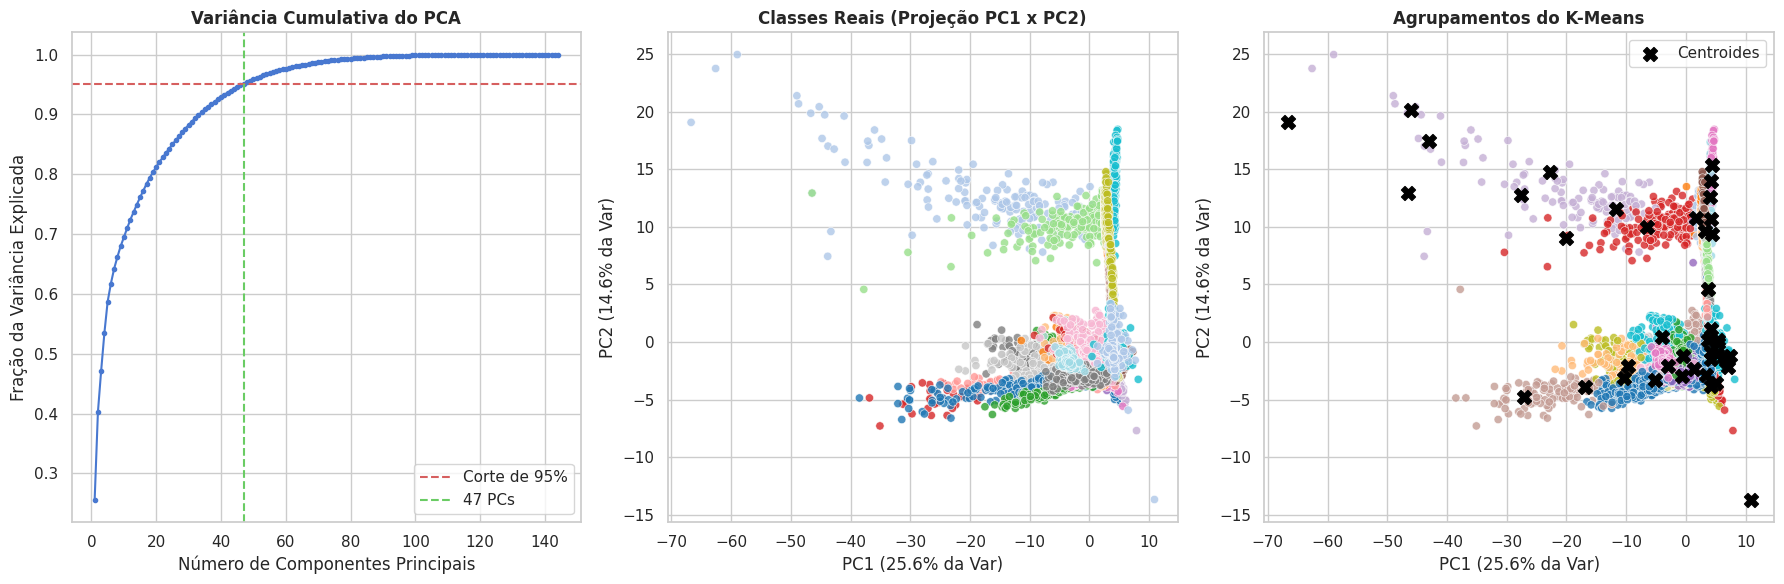

(array([36, 36, 36, ..., 22,  0,  0], shape=(7686,), dtype=int32),
 array([[ 4.47705832, -3.55874416,  0.56804551, ..., -0.96288412,
         -0.24459487, -0.49214031],
        [ 4.41130318, -3.99722304,  0.79475124, ..., -0.96567892,
          0.40654515,  0.16479396],
        [ 4.14554913, -3.70658672,  0.49404655, ..., -0.12981461,
          0.45012288, -0.00537446],
        ...,
        [ 4.0937829 , -1.01250235,  0.11505502, ..., -0.3970049 ,
         -0.13147054,  0.14781234],
        [ 4.01358588, -1.27549882,  0.10332367, ..., -0.05803771,
         -0.26821477,  0.11192363],
        [ 4.07480091, -1.35303092,  0.17323271, ...,  0.05129219,
         -0.26517986,  0.20562638]], shape=(7686, 47)),
 KMeans(n_clusters=42, n_init=10, random_state=42))

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#from sklearn.cluster import KMeans
def perform_pca_and_plot_clusters(X_raw, y_true, num_classes, class_names=None):
    """
    Executa a padronização matemática, PCA, clusterização e gera os gráficos de diagnóstico.
    """
    # 1. Padronização (Z-Score Normalization)
    # Transforma os dados para que mu = 0 e sigma = 1 para cada feature
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # 2. PCA Completo (para visualizar a curva de variância)
    pca_full = PCA().fit(X_scaled)
    variancia_cumulativa = np.cumsum(pca_full.explained_variance_ratio_)

    # 3. PCA Otimizado (Retendo 95% da informação para o K-Means)
    pca_95 = PCA(n_components=0.95, random_state=42)
    X_pca = pca_95.fit_transform(X_scaled)

    num_componentes_usados = X_pca.shape[1]
    print(f"[{num_componentes_usados}] Componentes Principais retiveram 95% da variância.")

    # 4. Clusterização K-Means no subespaço do PCA
    #kmeans = KMeans(n_clusters=num_classes, init='k-means++', n_init=10, random_state=42)
    y_pred = model_cluster.fit_predict(X_pca)

    # ==========================================
    # Geração dos Gráficos de Diagnóstico
    # ==========================================
    sns.set_theme(style="whitegrid", palette="muted")
    fig = plt.figure(figsize=(18, 6))

    # --- Gráfico 1: Curva de Variância Explicada (Scree Plot) ---
    # Mostra o quão esparsa ou densa é a informação nas suas features originais
    ax1 = fig.add_subplot(131)
    ax1.plot(range(1, len(variancia_cumulativa) + 1), variancia_cumulativa, marker='.', linestyle='-', color='b')
    ax1.axhline(y=0.95, color='r', linestyle='--', label='Corte de 95%')
    ax1.axvline(x=num_componentes_usados, color='g', linestyle='--', label=f'{num_componentes_usados} PCs')
    ax1.set_title("Variância Cumulativa do PCA", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Número de Componentes Principais")
    ax1.set_ylabel("Fração da Variância Explicada")
    ax1.legend()

    # --- Gráfico 2: Projeção 2D das Classes Reais (Ground Truth) ---
    # Plota as amostras usando PC1 (eixo X) e PC2 (eixo Y), colorindo pelas labels REAIS
    ax2 = fig.add_subplot(132)
    sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1],
        hue=y_true, palette="tab20", legend=False, alpha=0.8, ax=ax2
    )
    ax2.set_title("Classes Reais (Projeção PC1 x PC2)", fontsize=12, fontweight='bold')
    ax2.set_xlabel(f"PC1 ({pca_95.explained_variance_ratio_[0]*100:.1f}% da Var)")
    ax2.set_ylabel(f"PC2 ({pca_95.explained_variance_ratio_[1]*100:.1f}% da Var)")

    # --- Gráfico 3: Projeção 2D dos Clusters do K-Means ---
    # Plota as amostras usando PC1 e PC2, colorindo pelas labels PREVITAS pelo modelo
    ax3 = fig.add_subplot(133)
    sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1],
        hue=y_pred, palette="tab20", legend=False, alpha=0.8, ax=ax3
    )

    # Plotando os centroides matemáticos encontrados pelo K-Means
    centroides = kmeans.cluster_centers_
    ax3.scatter(centroides[:, 0], centroides[:, 1], s=100, c='black', marker='X', label='Centroides')
    ax3.set_title("Agrupamentos daa clusterização", fontsize=12, fontweight='bold')
    ax3.set_xlabel(f"PC1 ({pca_95.explained_variance_ratio_[0]*100:.1f}% da Var)")
    ax3.set_ylabel(f"PC2 ({pca_95.explained_variance_ratio_[1]*100:.1f}% da Var)")
    ax3.legend()

    plt.tight_layout()
    plt.show()

    return y_pred, X_pca, kmeans


perform_pca_and_plot_clusters(X_raw, y_true, num_classes, class_names=class_names)

Os resultados do aprendizado não supervisionado foram mistos, o plot é PC1vs PC2 é PC2 vs PC3 mostram que as classes apresentam alguma conexão geométrica do espaço de features trabalhando, indicando que o DWT foi capaz de extrair características relevantes para a diferenciação das classes. Todavia, o modelo de clusterização não conseguiu aproveitar isso para criar agrupamentos que correspondem às classes reais, indicando que a estrutura dos dados é mais complexa do que o Spectral pode capturar.